# Notebook 5: EDA — Análisis B (por cultivo)

**Objetivo**: explorar el dataset desagregado por cultivo para entender:
- Qué cultivos son los más relevantes en cada región (perfil productivo)
- Estacionalidad específica de cada cultivo (cuándo se cosecha qué)
- Sensibilidad climática diferencial entre cultivos
- Caracterización de la respuesta de cultivos andinos a la sequía 2022

**Inputs**:
- `dataset_por_cultivo.csv`: dataset completo (todos los cultivos con producción >0)
- `dataset_por_cultivo_filtrado.csv`: versión Pareto-80 (solo cultivos relevantes)

**Estructura**:
1. Carga y panorama general
2. Perfil productivo por región (top cultivos)
3. Estacionalidad por cultivo
4. Sensibilidad climática diferencial
5. Caso de estudio: respuesta de cultivos andinos en Puno a la sequía 2022
6. Conclusiones para el informe

In [38]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

sns.set_style('whitegrid')
plt.rcParams['figure.dpi'] = 100
plt.rcParams['font.size'] = 10
pd.set_option('display.max_columns', 30)

## 1. Carga y panorama general

In [39]:
# >>>>>>>>>>> AJUSTAR ESTA RUTA <<<<<<<<<<<
from pathlib import Path

ROOT = Path.cwd()
if ROOT.name == "SCRIPTS":
    ROOT = ROOT.parent

RUTA_OUTPUT = ROOT / "OUTPUTS"
RUTA_BASE = ROOT / "Datasets Originales"
RUTA_OUTPUT.mkdir(parents=True, exist_ok=True)

df = pd.read_csv(RUTA_OUTPUT / "dataset_por_cultivo.csv")
df_filt = pd.read_csv(RUTA_OUTPUT / "dataset_por_cultivo_filtrado.csv")

# Compatibilidad: datasets exportados con nombres legibles
_RENAME = {
    "piso_ecologico": "piso_asignado",
    "numero_mes": "mes_num",
    "mes": "mes_nombre",
    "produccion_ton": "produccion_mensual",
    "temp_promedio": "t2m", "temp_maxima": "t2m_max", "temp_minima": "t2m_min",
    "precipitacion": "prectotcorr", "humedad_relativa": "rh2m",
    "radiacion_solar": "allsky_sfc_sw_dwn", "velocidad_viento": "ws2m",
    "presion_atmosferica": "ps", "humedad_suelo": "gwetroot",
    "temp_superficie": "ts", "punto_rocio": "t2mdew", "humedad_especifica": "qv2m",
}
for nuevo, viejo in _RENAME.items():
    if nuevo in df.columns and viejo not in df.columns:
        df = df.rename(columns={nuevo: viejo})
for nuevo, viejo in _RENAME.items():
    if nuevo in df_filt.columns and viejo not in df_filt.columns:
        df_filt = df_filt.rename(columns={nuevo: viejo})


# Crear fecha y unidad
df['fecha'] = pd.to_datetime(dict(year=df['anio'], month=df['mes_num'], day=1))
df['unidad'] = df['region'] + ' - ' + df['piso_asignado']

print(f"Dataset completo:    {df.shape}")
print(f"Dataset filtrado:    {df_filt.shape}")
print(f"Cultivos únicos:     {df['cultivo'].nunique()}")
print(f"Combinaciones (region, cultivo) con producción >0: {df[df['produccion_mensual']>0][['region','cultivo']].drop_duplicates().shape[0]}")
print(f"\nMuestra:")
print(df.head(3))

Dataset completo:    (14400, 22)
Dataset filtrado:    (1728, 20)
Cultivos únicos:     54
Combinaciones (region, cultivo) con producción >0: 170

Muestra:
  region piso_asignado      distrito   cultivo  anio  mes_num mes_nombre  \
0    Ica         costa  Chincha Alta  aceituna  2020        1      Enero   
1    Ica         costa  Chincha Alta       aji  2020        1      Enero   
2    Ica         costa  Chincha Alta       ajo  2020        1      Enero   

   produccion_mensual    t2m  t2m_max  t2m_min  prectotcorr   rh2m  \
0                 0.0  21.96    27.55    18.21         0.12  78.45   
1               635.0  21.96    27.55    18.21         0.12  78.45   
2                12.0  21.96    27.55    18.21         0.12  78.45   

   allsky_sfc_sw_dwn  ws2m     ps  gwetroot     ts  t2mdew   qv2m      fecha  \
0              22.25  2.99  95.82      0.33  23.95   17.83  13.41 2020-01-01   
1              22.25  2.99  95.82      0.33  23.95   17.83  13.41 2020-01-01   
2              22.25

In [40]:
# Mapeo de códigos NASA POWER a etiquetas legibles
LABELS_CLIMA = {
    't2m': 'Temp. promedio (°C)',
    't2m_max': 'Temp. máxima (°C)',
    't2m_min': 'Temp. mínima (°C)',
    'prectotcorr': 'Precipitación (mm/día)',
    'rh2m': 'Humedad relativa (%)',
    'gwetroot': 'Humedad del suelo',
    'allsky_sfc_sw_dwn': 'Radiación solar (W/m²)',
    'ws2m': 'Velocidad viento (m/s)',
    'ps': 'Presión atmosférica (kPa)',
    'ts': 'Temp. superficie suelo (°C)',
    't2mdew': 'Punto de rocío (°C)',
    'qv2m': 'Humedad específica (g/kg)',
}

## 2. Perfil productivo por región

### 2.1 Top 10 cultivos por región

Para entender qué dominan económicamente cada región.

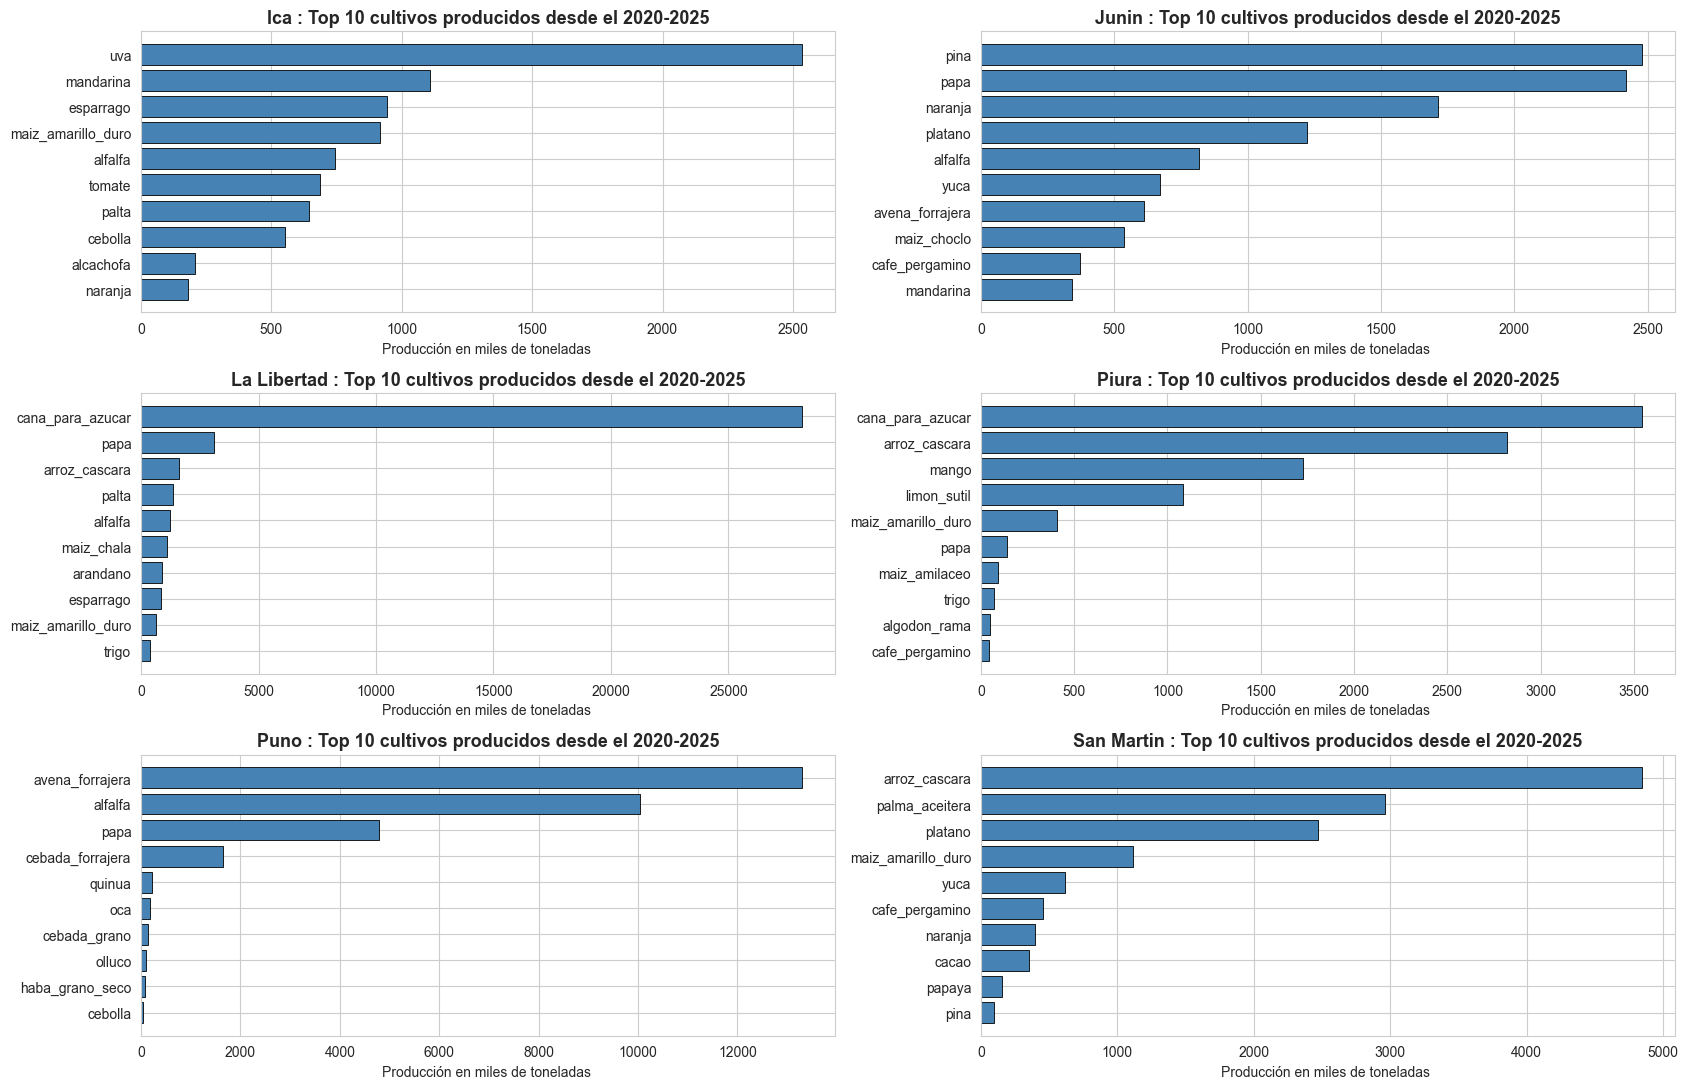

In [41]:
# Top 10 por región
fig, axes = plt.subplots(3, 2, figsize=(17, 11))
axes = axes.flatten()

regiones = sorted(df['region'].unique())
for i, region in enumerate(regiones):
    sub = (df[df['region']==region]
           .groupby('cultivo')['produccion_mensual']
           .sum().sort_values(ascending=False).head(10))
    sub_mil = sub / 1000
    
    axes[i].barh(sub_mil.index[::-1], sub_mil.values[::-1], color='steelblue', edgecolor='black', linewidth=0.6)
    axes[i].set_title(f'{region} : Top 10 cultivos producidos desde el 2020-2025', fontsize=13, fontweight='bold')
    axes[i].set_xlabel('Producción en miles de toneladas ', fontsize=10)

plt.tight_layout()
plt.show()

### 2.2 Concentración productiva (curva Lorenz por región)

¿Qué tan concentrada está la producción agrícola? Si pocos cultivos acumulan el grueso, la región es **dependiente** de ellos.

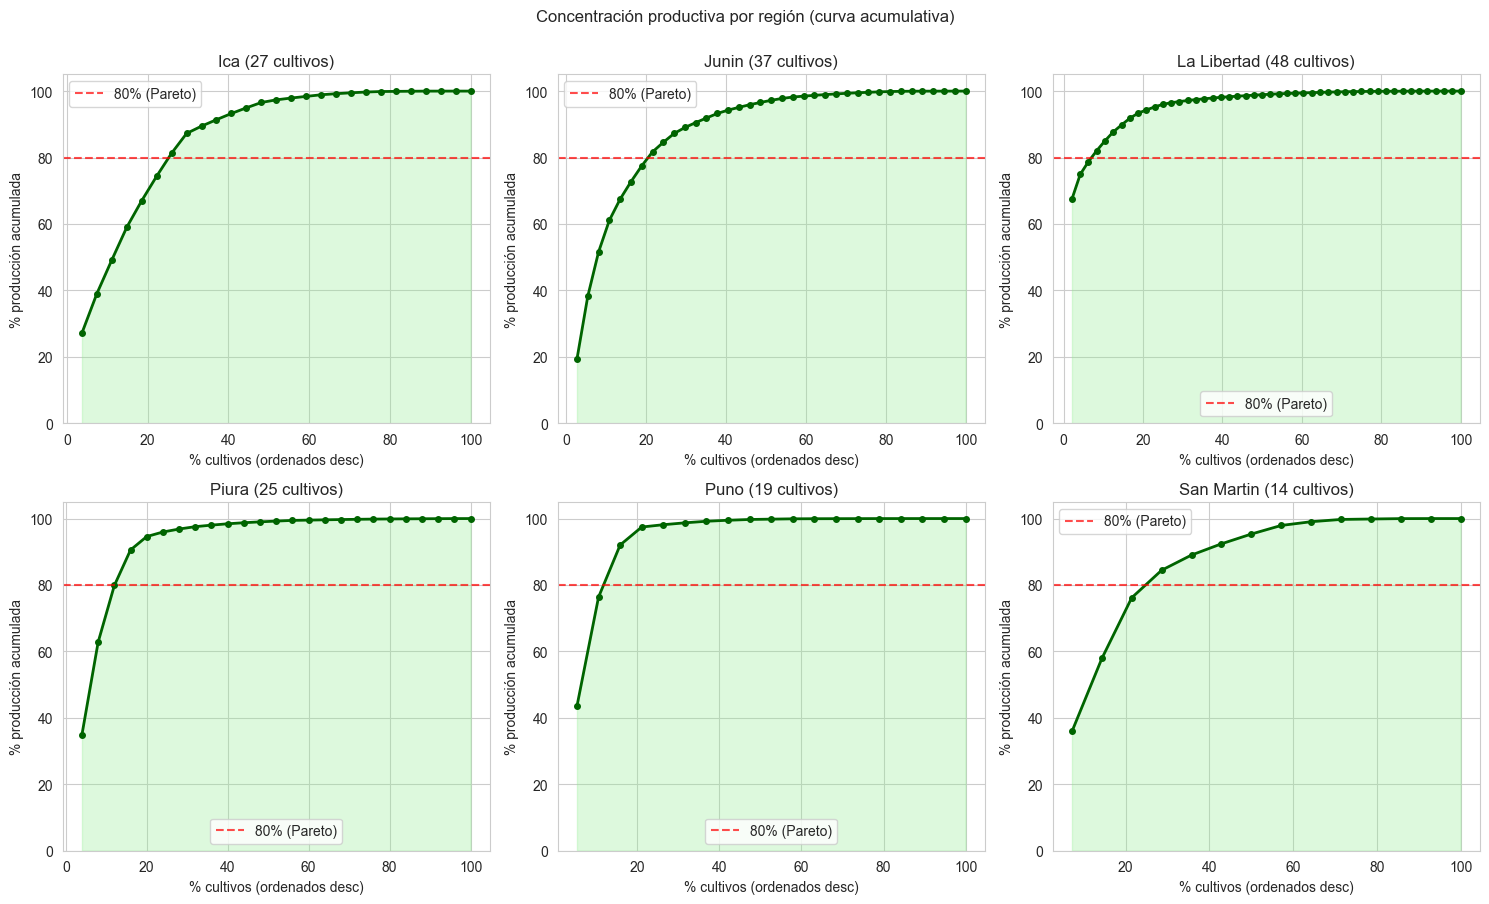

In [42]:
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()

for i, region in enumerate(regiones):
    sub = (df[df['region']==region]
           .groupby('cultivo')['produccion_mensual']
           .sum().sort_values(ascending=False))
    sub = sub[sub > 0]
    n = len(sub)
    acum_pct = sub.cumsum() / sub.sum() * 100
    x = np.arange(1, n + 1) / n * 100
    
    axes[i].plot(x, acum_pct.values, marker='o', linewidth=2, color='darkgreen', markersize=4)
    axes[i].axhline(80, ls='--', color='red', alpha=0.7, label='80% (Pareto)')
    axes[i].fill_between(x, acum_pct.values, color='lightgreen', alpha=0.3)
    axes[i].set_title(f'{region} ({n} cultivos)')
    axes[i].set_xlabel('% cultivos (ordenados desc)')
    axes[i].set_ylabel('% producción acumulada')
    axes[i].set_ylim(0, 105)
    axes[i].legend()

plt.suptitle('Concentración productiva por región (curva acumulativa)', y=1.0, fontsize=12)
plt.tight_layout()
plt.show()

## 3. Estacionalidad por cultivo

Para los cultivos del filtrado Pareto-80, vamos a ver cuándo se produce cada uno (calendario agrícola).

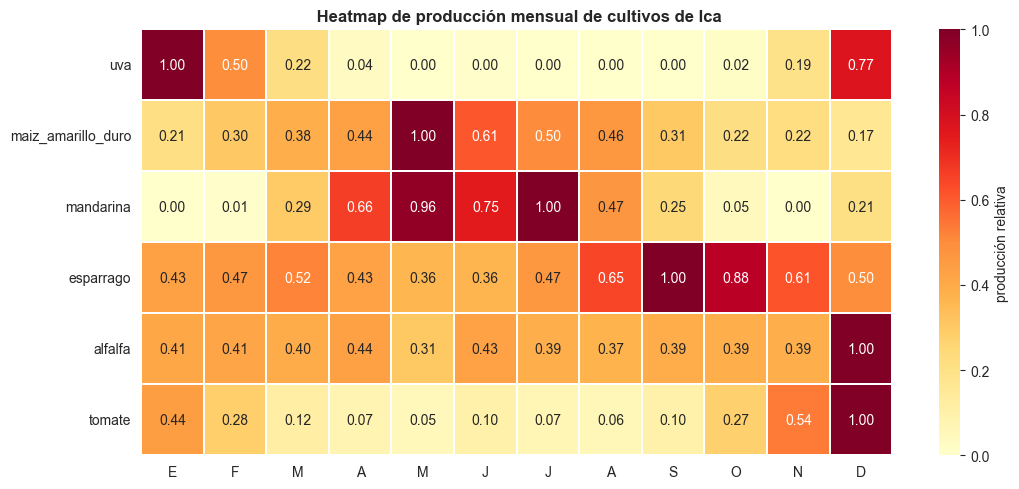

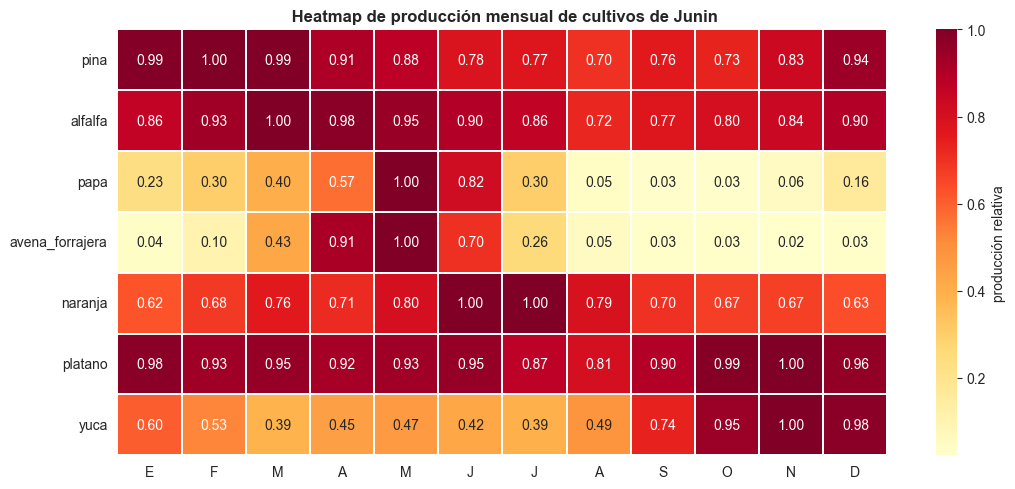

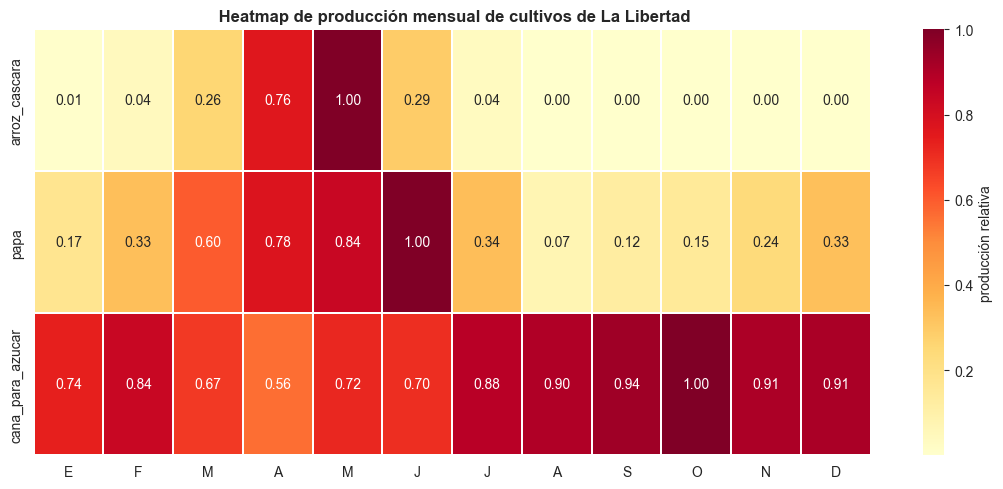

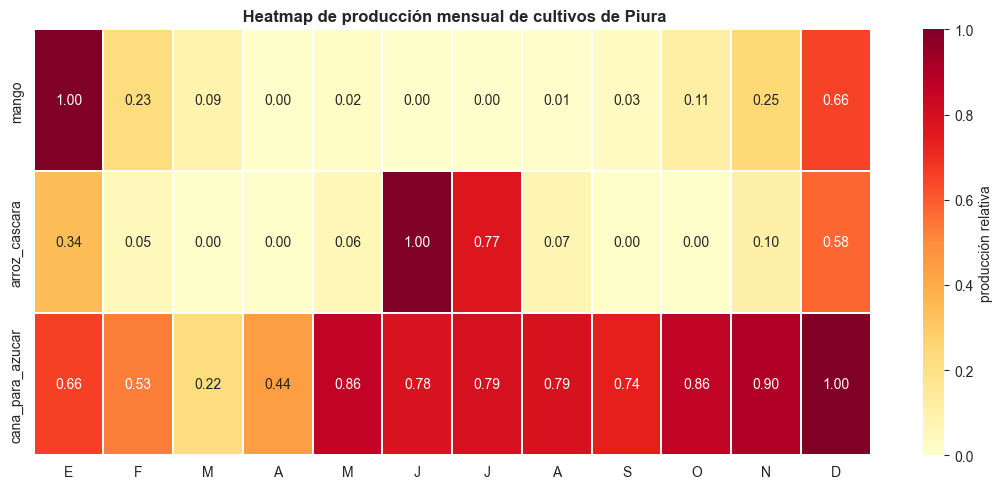

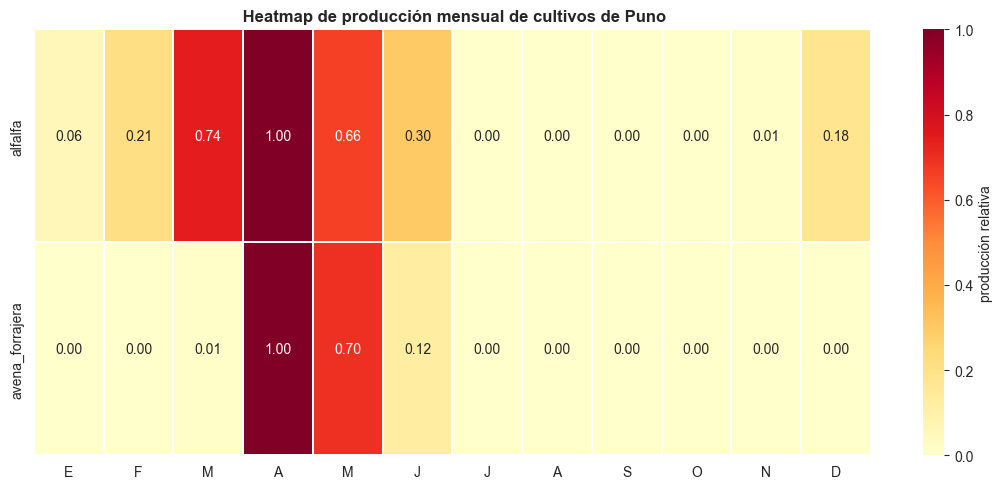

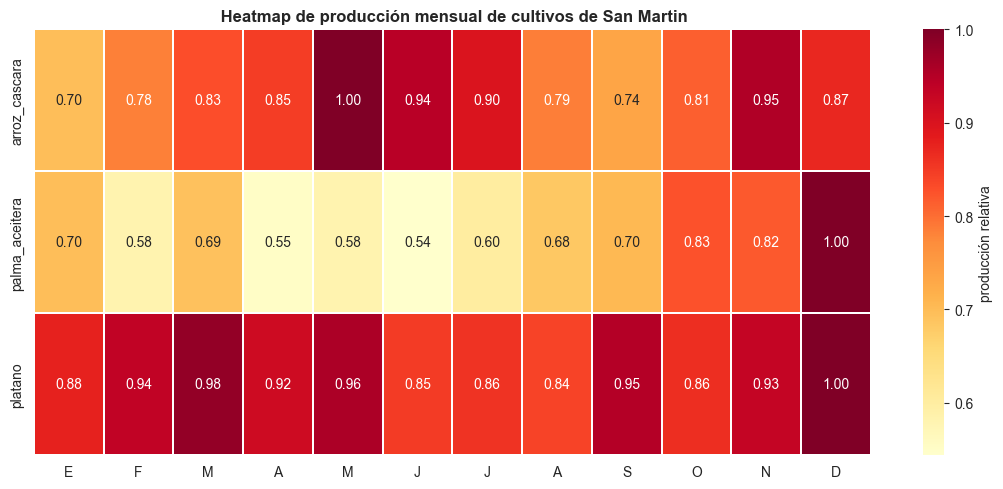

In [47]:
# Heatmap mes x cultivo, normalizado por cultivo (cada cultivo a 0-1)
def calendario_region(df, region, ax):
    sub = df[df['region']==region].copy()
    pivot = (sub.groupby(['cultivo','mes_num'])['produccion_mensual']
             .mean().unstack(fill_value=0))
    # Normalizar cada cultivo (fila) a 0-1
    pivot_norm = pivot.div(pivot.max(axis=1).replace(0, 1), axis=0)
    # Ordenar por mes pico
    mes_pico = pivot_norm.idxmax(axis=1)
    pivot_norm = pivot_norm.loc[mes_pico.sort_values().index]
    
    sns.heatmap(pivot_norm, ax=ax, cmap='YlOrRd', cbar_kws={'label':'producción relativa'},
                xticklabels=['E','F','M','A','M','J','J','A','S','O','N','D'], annot=True, fmt='.2f', linewidths=0.3)
    ax.set_title(f' Heatmap de producción mensual de cultivos de {region}', fontsize=12, fontweight='bold')
    ax.set_xlabel('')
    ax.set_ylabel('')

for region in regiones:
    fig, ax = plt.subplots(figsize=(11, max(5, df_filt[df_filt['region']==region]['cultivo'].nunique() * 0.3)))
    calendario_region(df_filt, region, ax)
    plt.tight_layout()
    plt.show()

## 4. Sensibilidad climática diferencial

Para los cultivos del filtrado Pareto-80, calculamos la correlación con cada variable climática.

**Importante**: estas son correlaciones lineales mensuales. NO implican causalidad — solo asociación. Sirven como **mapa de hipótesis** para modelado posterior.

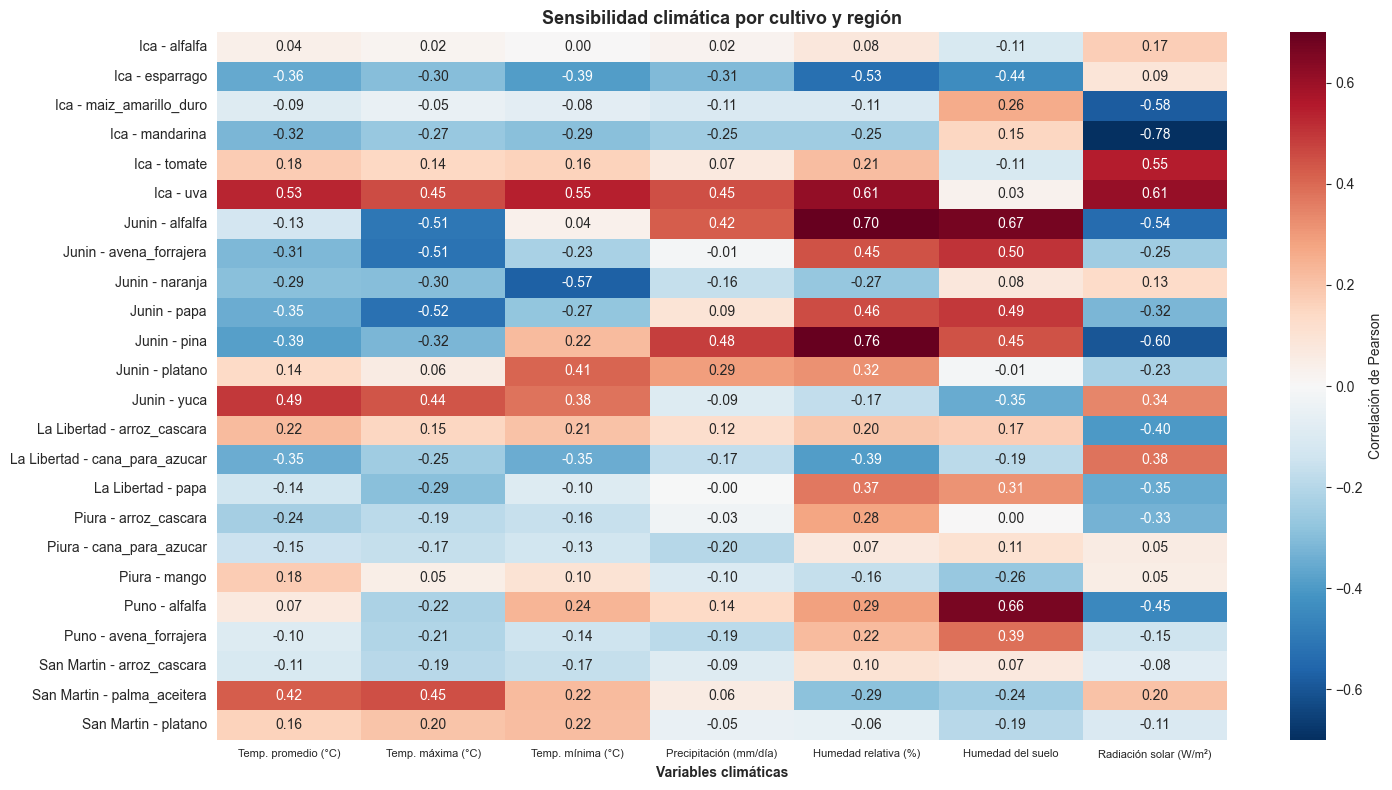

In [44]:
vars_clima = ['t2m','t2m_max','t2m_min','prectotcorr','rh2m','gwetroot','allsky_sfc_sw_dwn']

corrs = []
for (region, cultivo), sub in df_filt.groupby(['region','cultivo']):
    fila = {'region':region, 'cultivo':cultivo}
    for v in vars_clima:
        clean = sub[['produccion_mensual', v]].dropna()
        if len(clean) > 10:
            fila[v] = clean['produccion_mensual'].corr(clean[v])
        else:
            fila[v] = np.nan
    corrs.append(fila)

df_corr = pd.DataFrame(corrs)
df_corr['etiqueta'] = df_corr['region'] + ' - ' + df_corr['cultivo']

# Heatmap (todos los pares region-cultivo del Pareto-80)
df_corr_plot = df_corr.set_index('etiqueta')[vars_clima].sort_index().rename(columns=LABELS_CLIMA)
fig, ax = plt.subplots(figsize=(15, max(8, len(df_corr_plot) * 0.25)))
sns.heatmap(df_corr_plot, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
            vmin=-0.7, vmax=0.7, ax=ax, cbar_kws={'label':'Correlación de Pearson'})
ax.set_title('Sensibilidad climática por cultivo y región', fontsize=13, fontweight='bold')
ax.set_xlabel('Variables climáticas', fontsize=10, fontweight = 'bold')
ax.set_ylabel('')
plt.xticks(rotation=0, fontsize=8)
plt.yticks(fontsize=10)
plt.tight_layout()
plt.show()

### 4.1 Top correlaciones absolutas

Para identificar qué pares (cultivo, variable) son más sensibles.

In [45]:
top_corrs = []
for _, row in df_corr.iterrows():
    for v in vars_clima:
        if pd.notna(row[v]):
            top_corrs.append({
                'region': row['region'],
                'cultivo': row['cultivo'],
                'variable': v,
                'corr': row[v],
                'abs_corr': abs(row[v])
            })

top_df = pd.DataFrame(top_corrs).sort_values('abs_corr', ascending=False).head(20)
top_df['variable_legible'] = top_df['variable'].map(LABELS_CLIMA)
top_df['corr'] = top_df['corr'].round(3)
print("Top 20 correlaciones cultivo-clima (en valor absoluto):")
print(top_df[['region','cultivo','variable_legible','corr']].to_string(index=False))

Top 20 correlaciones cultivo-clima (en valor absoluto):
region            cultivo       variable_legible   corr
   Ica          mandarina Radiación solar (W/m²) -0.780
 Junin               pina   Humedad relativa (%)  0.756
 Junin            alfalfa   Humedad relativa (%)  0.698
 Junin            alfalfa      Humedad del suelo  0.670
  Puno            alfalfa      Humedad del suelo  0.664
   Ica                uva   Humedad relativa (%)  0.615
   Ica                uva Radiación solar (W/m²)  0.611
 Junin               pina Radiación solar (W/m²) -0.597
   Ica maiz_amarillo_duro Radiación solar (W/m²) -0.583
 Junin            naranja      Temp. mínima (°C) -0.572
   Ica             tomate Radiación solar (W/m²)  0.547
   Ica                uva      Temp. mínima (°C)  0.546
 Junin            alfalfa Radiación solar (W/m²) -0.539
   Ica                uva    Temp. promedio (°C)  0.535
   Ica          esparrago   Humedad relativa (%) -0.530
 Junin               papa      Temp. máxima (°C)

## 5. Caso de estudio: Puna alta (Puno) durante la sequía 2022

Vamos a verificar la observación que hicimos en el EDA regional: **los cultivos andinos tradicionales (papa, quinua, oca, olluco) cayeron mucho más que la avena forrajera durante 2022**, lo que justifica el análisis desagregado por cultivo.

Producción anual relativa a 2020 (%):
anio               2020  2021  2022  2023   2024   2025
cultivo                                                
avena_forrajera   100.0  55.3  71.4  57.7  179.0  147.4
cebada_forrajera  100.0  47.8  44.7  46.9  110.7   90.4
cebada_grano      100.0  47.9  50.1  50.0  138.3  107.1
oca               100.0  59.7  38.4  71.0  178.0  130.2
olluco            100.0  59.3  44.6  55.6  119.0  107.8
papa              100.0  75.4  52.8  72.4  147.8  133.4
quinua            100.0  76.3  35.9  84.6  144.3   98.2


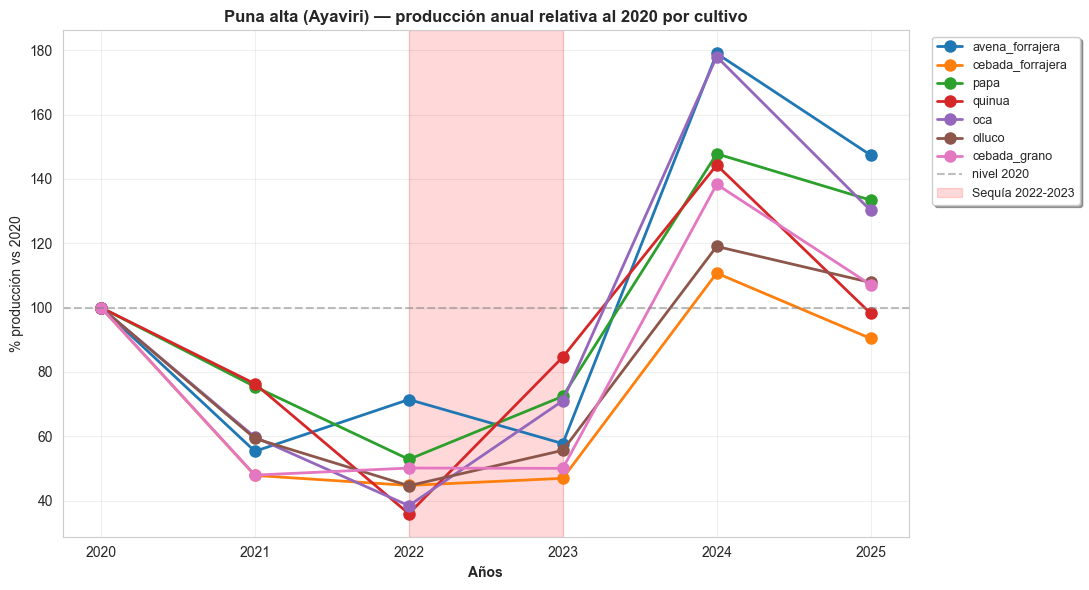


>>> Interpretación esperada:
- Cultivos andinos tradicionales (papa, quinua, oca, olluco): caída pronunciada en 2022
- Avena forrajera: caída moderada (resistencia climática mayor)
- Recuperación 2024 más fuerte en cultivos forrajeros que en andinos tradicionales


In [49]:
cultivos_puna = ['avena_forrajera','cebada_forrajera','papa','quinua','oca','olluco','cebada_grano']

puna = df[(df['region']=='Puno') & (df['piso_asignado']=='puna_alta') &
          (df['cultivo'].isin(cultivos_puna))].copy()

# Producción anual por cultivo (porcentaje vs 2020)
prod_anual = puna.groupby(['cultivo','anio'])['produccion_mensual'].sum().unstack()
pct_vs_2020 = (prod_anual.div(prod_anual[2020], axis=0) * 100).round(1)

print("Producción anual relativa a 2020 (%):")
print(pct_vs_2020)

# Visualizar
fig, ax = plt.subplots(figsize=(11, 6))
for cultivo in cultivos_puna:
    if cultivo in pct_vs_2020.index:
        ax.plot(pct_vs_2020.columns, pct_vs_2020.loc[cultivo].values, 
                marker='o', linewidth=2, label=cultivo, markersize=8)

ax.axhline(100, ls='--', color='gray', alpha=0.5, label='nivel 2020')
ax.axvspan(2022, 2023, alpha=0.15, color='red', label='Sequía 2022-2023')
ax.set_title('Puna alta (Ayaviri) — producción anual relativa al 2020 por cultivo', fontsize=12, fontweight='bold')
ax.set_xlabel('Años', fontsize=10, fontweight='bold')
ax.set_ylabel('% producción vs 2020')
ax.legend(loc='upper left', bbox_to_anchor=(1.02, 1), fontsize=9, shadow=True)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n>>> Interpretación esperada:")
print("- Cultivos andinos tradicionales (papa, quinua, oca, olluco): caída pronunciada en 2022")
print("- Avena forrajera: caída moderada (resistencia climática mayor)")
print("- Recuperación 2024 más fuerte en cultivos forrajeros que en andinos tradicionales")

### 5.1 Validación cruzada: ¿el patrón es solo de Puno o se ve en otros pisos andinos?

Comparemos con La Libertad - sierra (Huamachuco) que también produce papa y cebada.

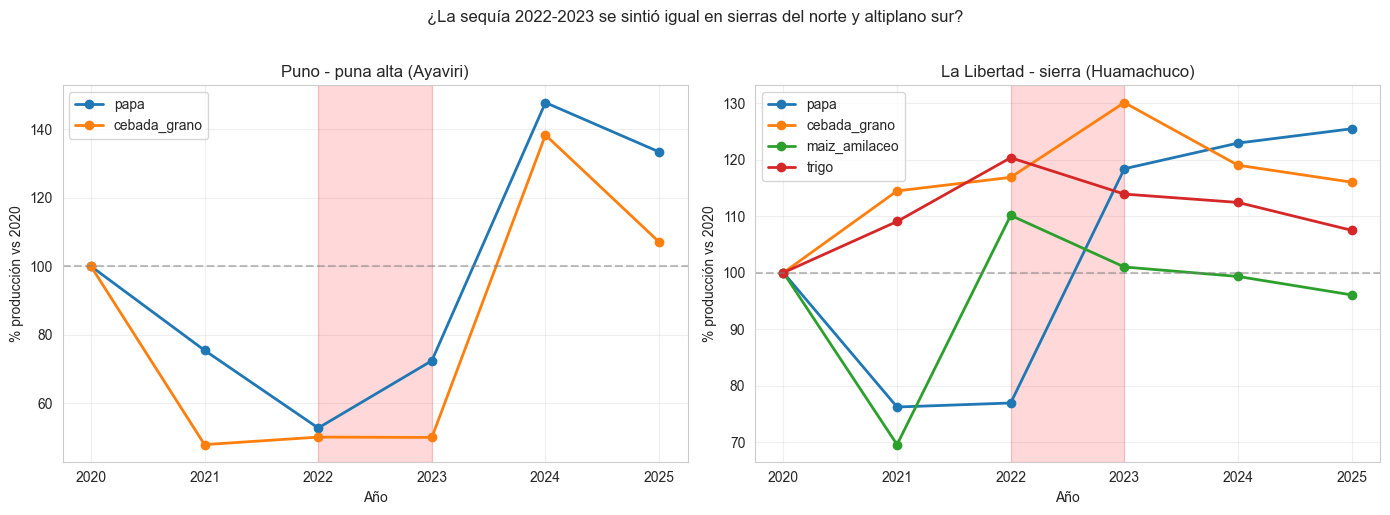


>>> Lectura: si La Libertad sierra NO muestra caída marcada en 2022 mientras Puno sí,
>>> entonces la sequía 2022-2023 fue un fenómeno específico del altiplano sur,
>>> no un evento andino general.


In [9]:
cultivos_andinos = ['papa', 'cebada_grano', 'maiz_amilaceo', 'trigo']

# Comparar Puno-puna_alta vs La Libertad-sierra para los mismos cultivos
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, (region, piso, titulo) in zip(axes, [
    ('Puno', 'puna_alta', 'Puno - puna alta (Ayaviri)'),
    ('La Libertad', 'sierra', 'La Libertad - sierra (Huamachuco)')
]):
    sub = df[(df['region']==region) & (df['piso_asignado']==piso) &
             (df['cultivo'].isin(cultivos_andinos))]
    prod = sub.groupby(['cultivo','anio'])['produccion_mensual'].sum().unstack()
    pct = prod.div(prod[2020], axis=0) * 100
    
    for cultivo in cultivos_andinos:
        if cultivo in pct.index:
            ax.plot(pct.columns, pct.loc[cultivo].values, marker='o', label=cultivo, linewidth=2)
    
    ax.axhline(100, ls='--', color='gray', alpha=0.5)
    ax.axvspan(2022, 2023, alpha=0.15, color='red')
    ax.set_title(titulo)
    ax.set_xlabel('Año')
    ax.set_ylabel('% producción vs 2020')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('¿La sequía 2022-2023 se sintió igual en sierras del norte y altiplano sur?', y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

print("\n>>> Lectura: si La Libertad sierra NO muestra caída marcada en 2022 mientras Puno sí,")
print(">>> entonces la sequía 2022-2023 fue un fenómeno específico del altiplano sur,")
print(">>> no un evento andino general.")

## 6. Conclusiones del EDA del Análisis B

| Hallazgo | Evidencia |
|---|---|
| Concentración productiva alta | 2-3 cultivos acumulan el 80% en regiones como La Libertad y Piura |
| Estacionalidad bien definida por cultivo | Calendarios muestran ventanas claras de cosecha (espárrago, uva, café, etc.) |
| Sensibilidad climática diferencial | Algunos cultivos muestran correlaciones fuertes (>0.4) con variables específicas, otros casi nulas |
| Cultivos andinos vulnerables a sequía | Caída diferenciada en Puno 2022: tradicionales (-50/-65%) vs forrajeros (-29%) |
| Geografía importa | Sequía 2022 mucho más severa en altiplano sur que en sierras del norte |

**Próximos pasos posibles**:
- Notebook 6: limpieza informada (NaN, outliers) basada en hallazgos del EDA
- Notebook 7+: modelado (clustering, predicción, vulnerabilidad)
- Documentación metodológica con los hallazgos para informe final